---
# In this file i will measure the EW of Halpha and (Hbeta+[OIII] doublet) emission lines

In [4]:
import os
import pathlib

import warnings
warnings.filterwarnings("ignore")

import FunctionLib as FL
from tqdm import tqdm

import numpy as np
import pandas as pd
import scipy
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit

import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['font.family'] = 'serif'

import astropy
import astropy.units as u
import seaborn as sns

DJAv4Catalog = FL.Spectrum_Catalog()
DJAv4Catalog.load_from_pkl(('./DJAV4.2Catalog.pkl'))
print(DJAv4Catalog.sample_num())
DJAv4Catalog.to_dataframe()

458


,survey_id_subid,prism_filepath,prism_redshift,determined_redshift,grating_filepaths,grating_redshifts,file_count,available_filters,properties,survey_id,sample_flag,reason_for_exclusion,grating_slitloss_correction,grating_within_coverage,lines_fit,s3fit_result_path,line_ratios,dust_curve_parameters
0,snh0pe-v4_4446_102,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,0.2259,0.2259,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': nan, 'g235m-f170lp': nan}",3,"{g235m-f170lp, prism-clear, g140m-f100lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3, redshift_...",{},{},{},None,{},{}
1,snh0pe-v4_4446_143,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.6318,1.6311,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.6313, 'g235m-f170lp': 1.6309}",3,"{g235m-f170lp, prism-clear, g140m-f100lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3, redshift_...",{},{},{},None,{},{}
2,snh0pe-v4_4446_285,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,0.4446,0.4462,{'g235m-f170lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g235m-f170lp': 0.4462, 'g140m-f100lp': 0.4462}",3,"{g235m-f170lp, prism-clear, g140m-f100lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3, redshift_...",{},{},{},None,{},{}
3,snh0pe-v4_4446_29,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.7834,1.77975,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.7799, 'g235m-f170lp': 1.7796}",3,"{g235m-f170lp, prism-clear, g140m-f100lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3, redshift_...",{},{},{},None,{},{}
4,snh0pe-v4_4446_123,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.7855,1.7855,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.7855, 'g235m-f170lp': 1.7851}",3,"{g235m-f170lp, prism-clear, g140m-f100lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3, redshift_...",{},{},{},None,{},{}
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43037,glimpse-obs02-v4_9223_9152,None,None,5.5385,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 5.5385},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,"[no_prism_spectrum, no_prism_spectrum, no_pris...",{},{},{},None,{},{}
43038,glimpse-obs02-v4_9223_98001,None,None,2.6322,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 2.6322},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,"[no_prism_spectrum, no_prism_spectrum, no_pris...",{},{},{},None,{},{}
43039,glimpse-obs02-v4_9223_47046,None,None,4.3554,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 4.3554},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,"[no_prism_spectrum, no_prism_spectrum, no_pris...",{},{},{},None,{},{}
43040,glimpse-obs02-v4_9223_45350,None,None,1.3675,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 1.3675},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,"[no_prism_spectrum, no_prism_spectrum, no_pris...",{},{},{},None,{},{}


{'prism_filepath': '/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_prism-clear_4446_104.spec.fits', 'prism_redshift': <Quantity 3.1147>, 'determined_redshift': <Quantity 3.1096>, 'grating_filepaths': {'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_g140m-f100lp_4446_104.spec.fits', 'g235m-f170lp': '/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_g235m-f170lp_4446_104.spec.fits'}, 'grating_redshifts': {'g140m-f100lp': <Quantity 3.1099>, 'g235m-f170lp': <Quantity 3.1093>}, 'file_count': 3, 'available_filters': {'g235m-f170lp', 'prism-clear', 'g140m-f100lp'}, 'properties': {'redshift_conflict': False}, 'survey_id': 'snh0pe-v4', 'sample_flag': True, 'reason_for_exclusion': [], 'grating_slitloss_correction': {'halpha_psf_fraction_f100lp': np.float64(0.8619949188721704), 'hbeta_psf_fraction_f100lp': np.float64(0.8842540066518874), 'halpha_psf_fraction_f170lp': np.float64(0.8619949188721704), 'hbeta_psf_fraction_f170lp': np.float64(0.8842540066518874)}, 'grating_within_coverage': {'g

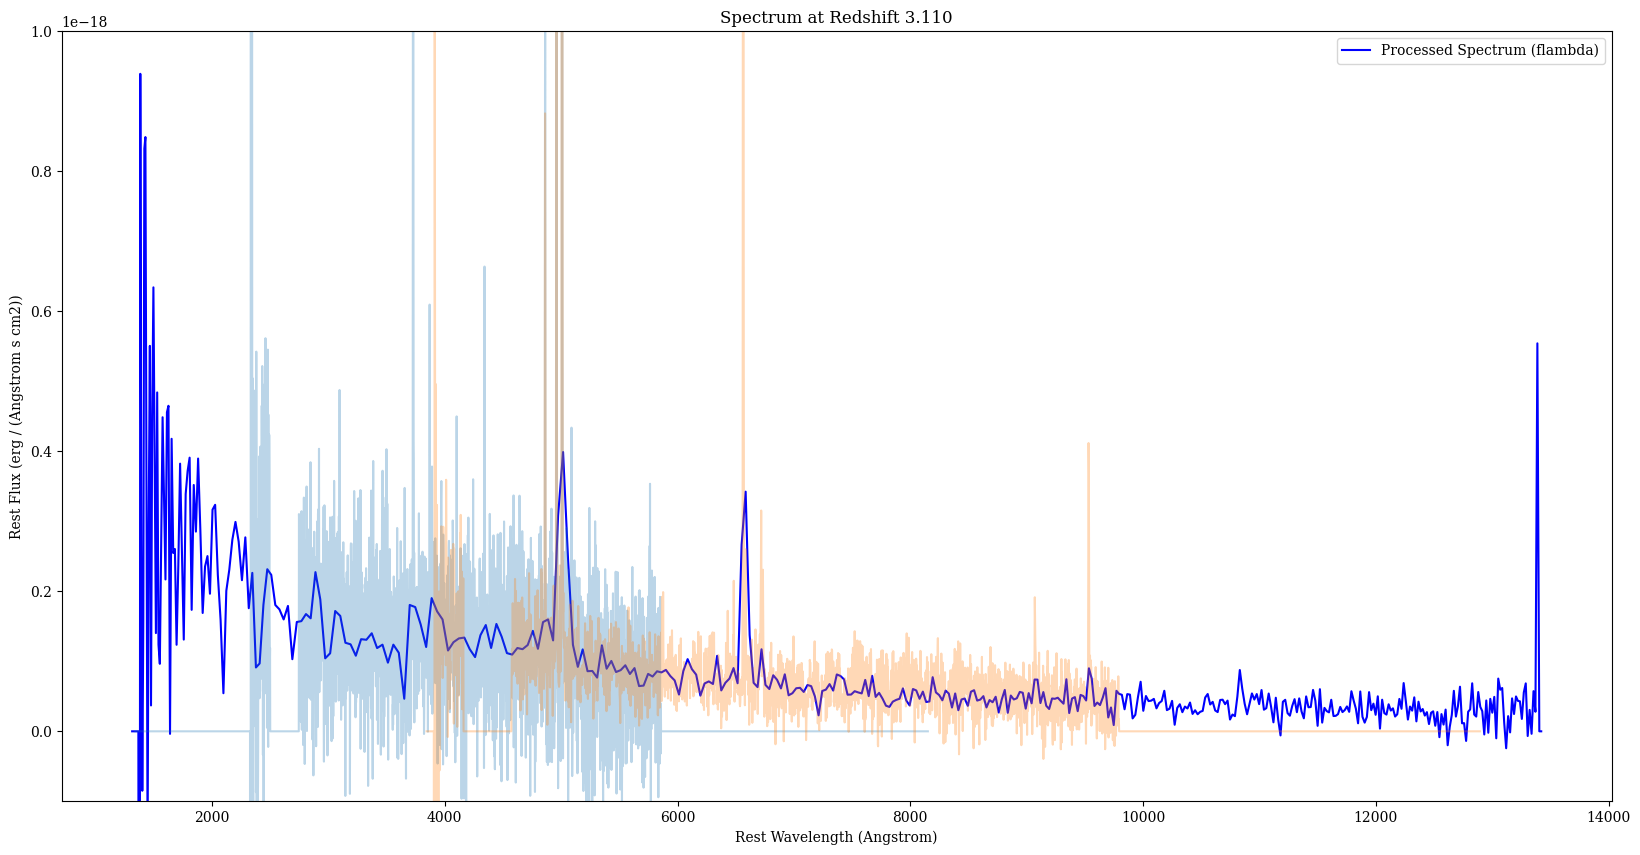

{'prism_filepath': '/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_prism-clear_4446_511.spec.fits', 'prism_redshift': <Quantity 3.3266>, 'determined_redshift': <Quantity 3.3235>, 'grating_filepaths': {'g235m-f170lp': '/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_g235m-f170lp_4446_511.spec.fits', 'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_g140m-f100lp_4446_511.spec.fits'}, 'grating_redshifts': {'g235m-f170lp': <Quantity 3.3235>, 'g140m-f100lp': <Quantity 3.3235>}, 'file_count': 3, 'available_filters': {'g235m-f170lp', 'prism-clear', 'g140m-f100lp'}, 'properties': {'redshift_conflict': False}, 'survey_id': 'snh0pe-v4', 'sample_flag': True, 'reason_for_exclusion': [], 'grating_slitloss_correction': {'halpha_psf_fraction_f170lp': np.float64(0.8973304508801143), 'hbeta_psf_fraction_f170lp': np.float64(0.9165020923896814), 'halpha_psf_fraction_f100lp': np.float64(0.8973304508801143), 'hbeta_psf_fraction_f100lp': np.float64(0.9165020923896814)}, 'grating_within_coverage': {'g

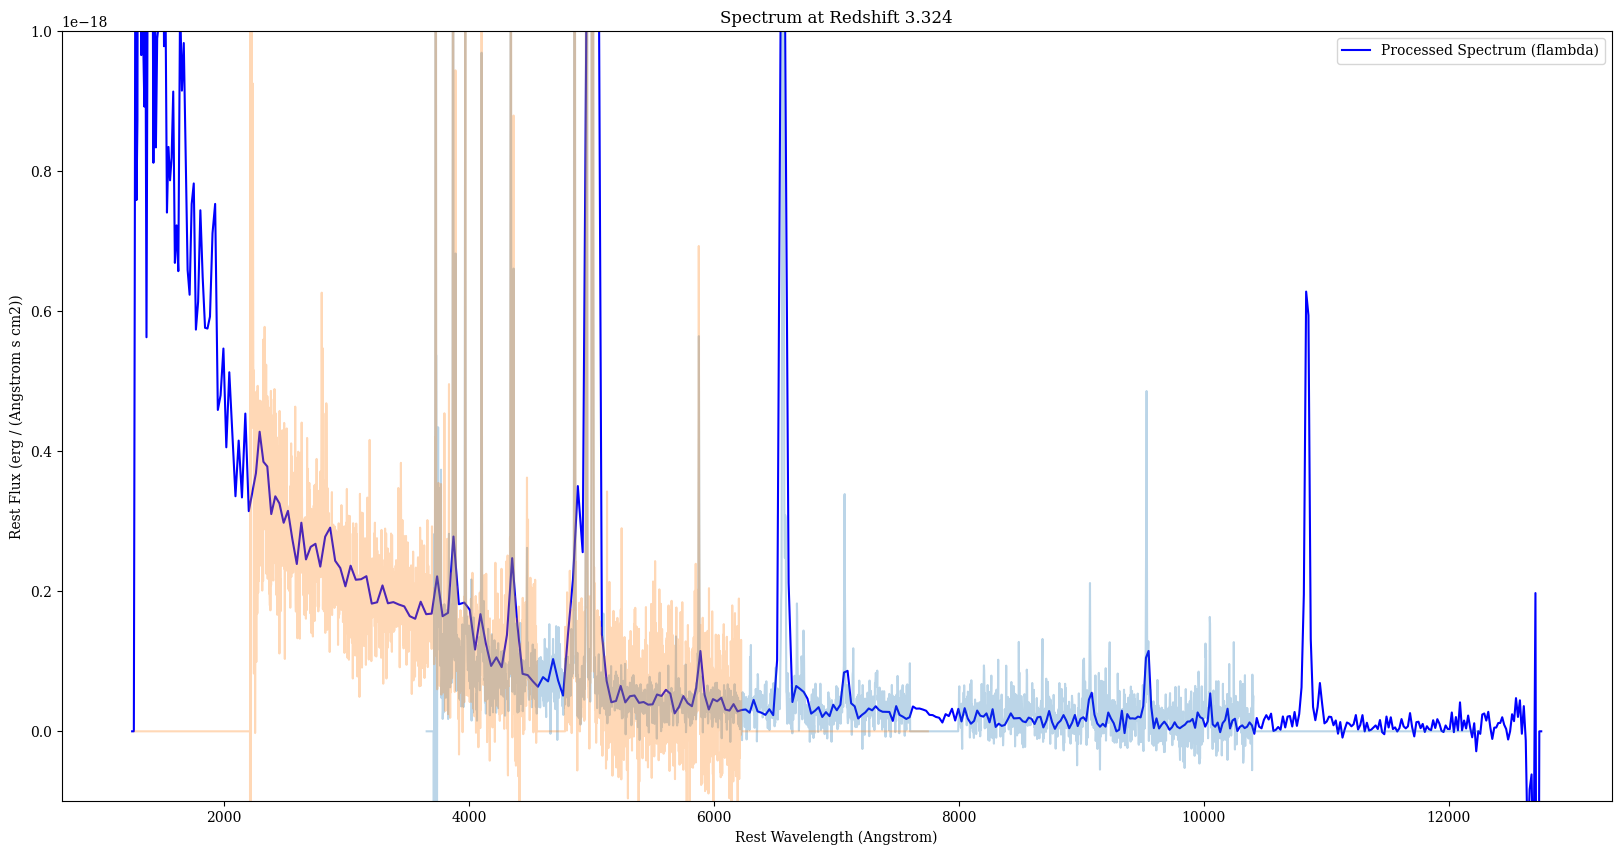

{'prism_filepath': '/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_prism-clear_4446_19.spec.fits', 'prism_redshift': <Quantity 3.9612>, 'determined_redshift': <Quantity 3.95125>, 'grating_filepaths': {'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_g140m-f100lp_4446_19.spec.fits', 'g235m-f170lp': '/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_g235m-f170lp_4446_19.spec.fits'}, 'grating_redshifts': {'g140m-f100lp': <Quantity 3.9516>, 'g235m-f170lp': <Quantity 3.9509>}, 'file_count': 3, 'available_filters': {'g235m-f170lp', 'prism-clear', 'g140m-f100lp'}, 'properties': {'redshift_conflict': False}, 'survey_id': 'snh0pe-v4', 'sample_flag': True, 'reason_for_exclusion': [], 'grating_slitloss_correction': {'halpha_psf_fraction_f100lp': np.float64(0.8559870421471091), 'hbeta_psf_fraction_f100lp': np.float64(0.8630961433704926), 'halpha_psf_fraction_f170lp': np.float64(0.8559870421471091), 'hbeta_psf_fraction_f170lp': np.float64(0.8630961433704926)}, 'grating_within_coverage': {'g23

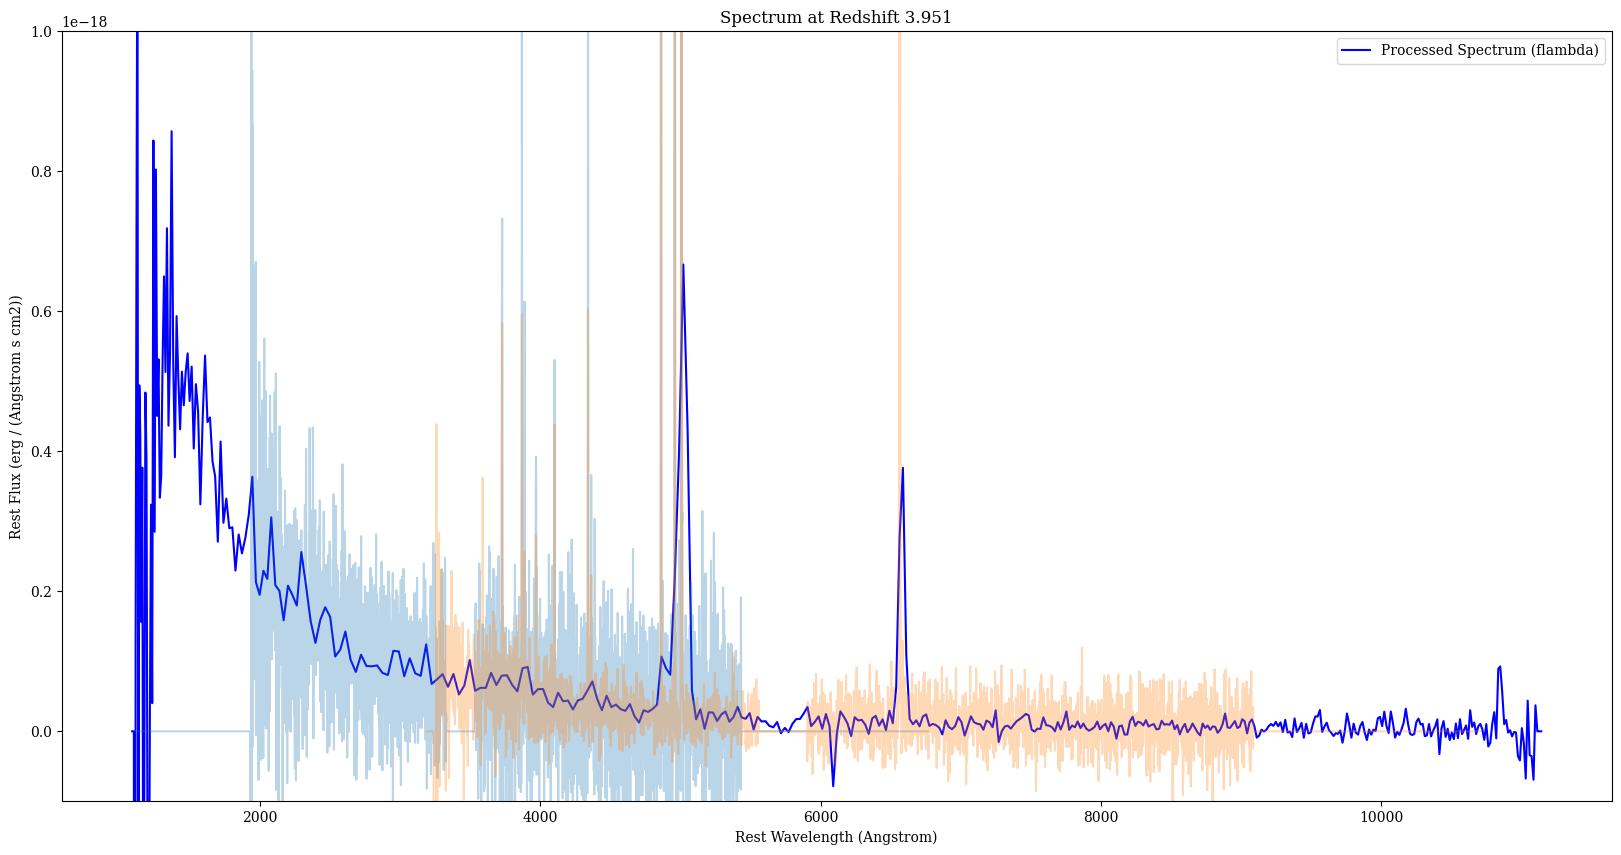

{'prism_filepath': '/home/xingyaocai/DJAv4.2/jades-gdn2-v4/jades-gdn2-v4_prism-clear_1181_3008.spec.fits', 'prism_redshift': <Quantity 4.5321>, 'determined_redshift': <Quantity 4.5337>, 'grating_filepaths': {'g235m-f170lp': '/home/xingyaocai/DJAv4.2/jades-gdn2-v4/jades-gdn2-v4_g235m-f170lp_1181_3008.spec.fits', 'g140m-f070lp': '/home/xingyaocai/DJAv4.2/jades-gdn2-v4/jades-gdn2-v4_g140m-f070lp_1181_3008.spec.fits', 'g395m-f290lp': '/home/xingyaocai/DJAv4.2/jades-gdn2-v4/jades-gdn2-v4_g395m-f290lp_1181_3008.spec.fits'}, 'grating_redshifts': {'g235m-f170lp': <Quantity 4.5339>, 'g140m-f070lp': <Quantity 4.5346>, 'g395m-f290lp': <Quantity 4.5335>}, 'file_count': 4, 'available_filters': {'g235m-f170lp', 'prism-clear', 'g395m-f290lp', 'g140m-f070lp'}, 'properties': {'redshift_conflict': False}, 'survey_id': 'jades-gdn2-v4', 'sample_flag': True, 'reason_for_exclusion': [], 'grating_slitloss_correction': {'halpha_psf_fraction_f170lp': np.float64(0.8368015863770772), 'hbeta_psf_fraction_f170lp':

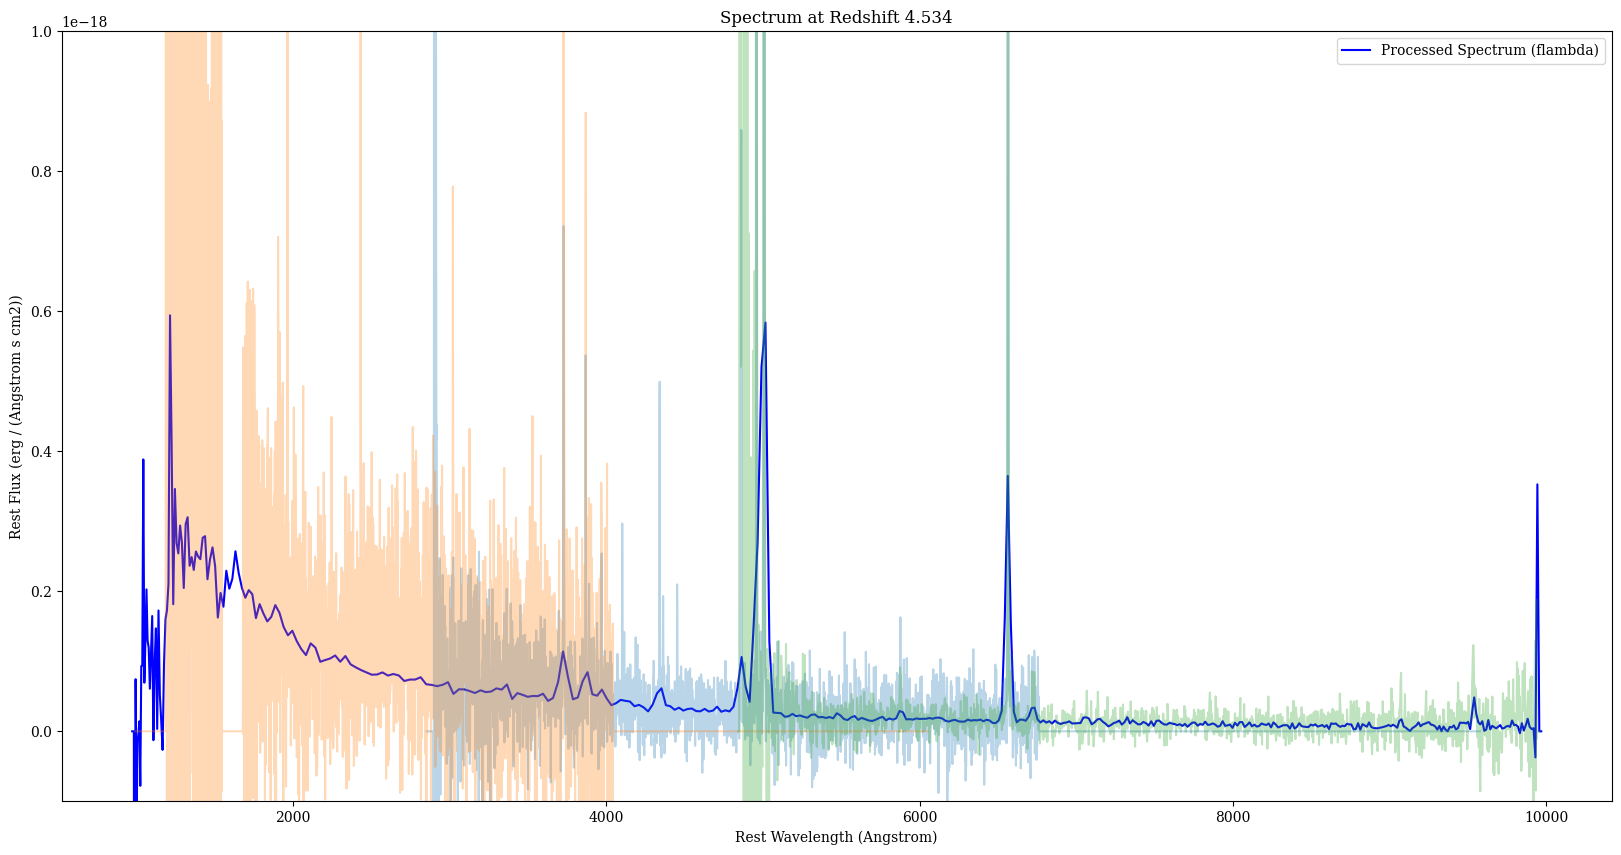

{'prism_filepath': '/home/xingyaocai/DJAv4.2/jades-gdn2-v4/jades-gdn2-v4_prism-clear_1181_2347.spec.fits', 'prism_redshift': <Quantity 5.6401>, 'determined_redshift': <Quantity 5.6363>, 'grating_filepaths': {'g395m-f290lp': '/home/xingyaocai/DJAv4.2/jades-gdn2-v4/jades-gdn2-v4_g395m-f290lp_1181_2347.spec.fits', 'g140m-f070lp': '/home/xingyaocai/DJAv4.2/jades-gdn2-v4/jades-gdn2-v4_g140m-f070lp_1181_2347.spec.fits', 'g235m-f170lp': '/home/xingyaocai/DJAv4.2/jades-gdn2-v4/jades-gdn2-v4_g235m-f170lp_1181_2347.spec.fits'}, 'grating_redshifts': {'g395m-f290lp': <Quantity 5.6363>, 'g140m-f070lp': <Quantity 5.6363>, 'g235m-f170lp': <Quantity 5.6363>}, 'file_count': 4, 'available_filters': {'g235m-f170lp', 'prism-clear', 'g395m-f290lp', 'g140m-f070lp'}, 'properties': {'redshift_conflict': False}, 'survey_id': 'jades-gdn2-v4', 'sample_flag': True, 'reason_for_exclusion': [], 'grating_slitloss_correction': {'halpha_psf_fraction_f290lp': np.float64(0.8043943772671948), 'hbeta_psf_fraction_f290lp':

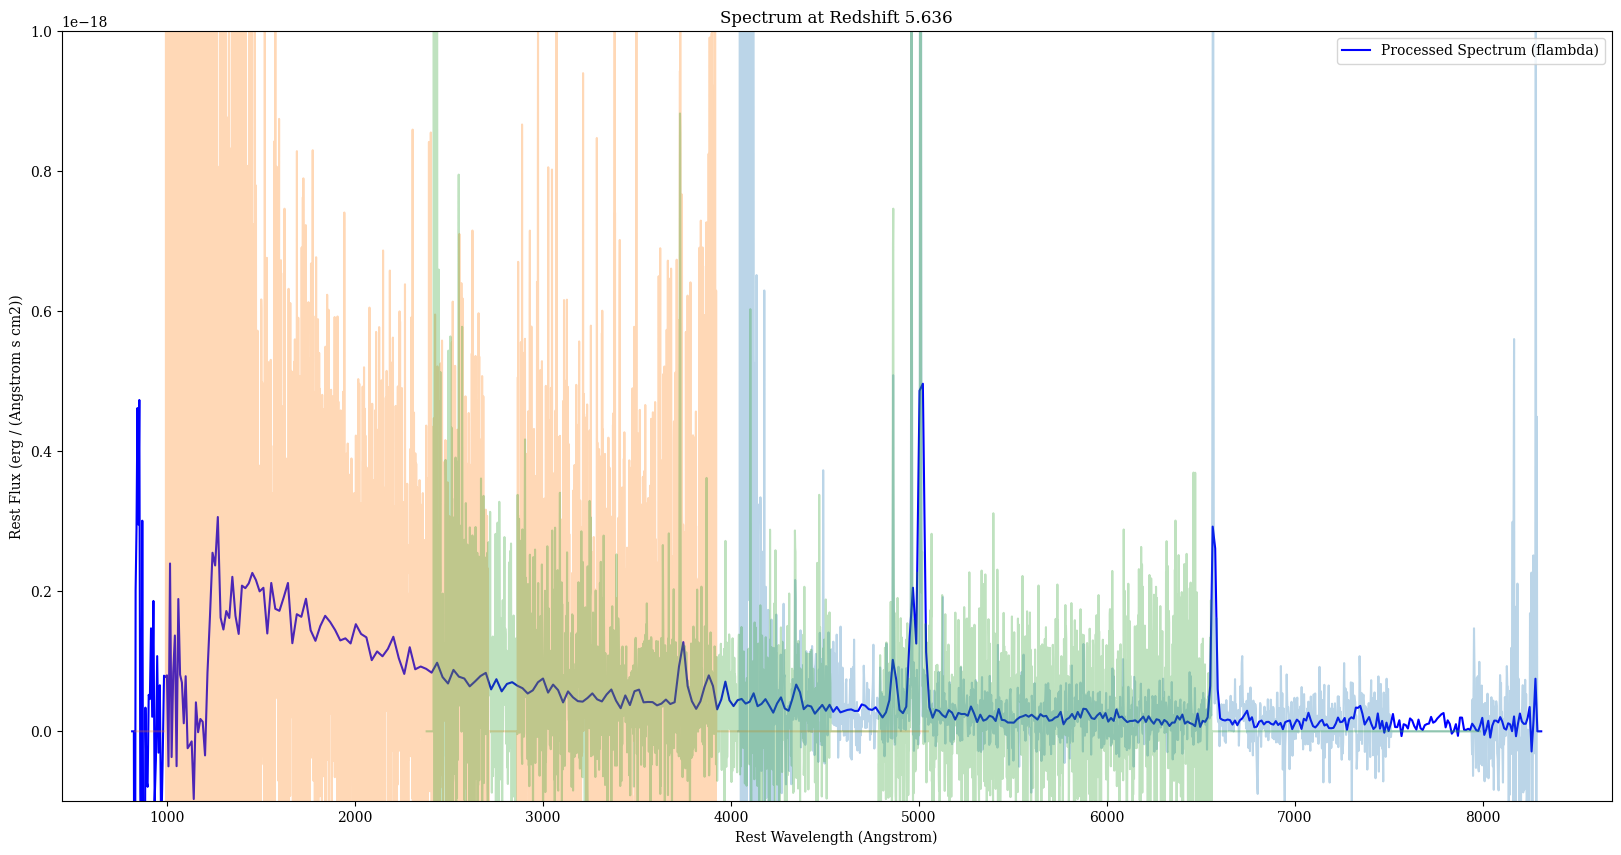

{'prism_filepath': '/home/xingyaocai/DJAv4.2/jades-gdn2-v4/jades-gdn2-v4_prism-clear_1181_1580.spec.fits', 'prism_redshift': <Quantity 5.3031>, 'determined_redshift': <Quantity 5.2987>, 'grating_filepaths': {'g395m-f290lp': '/home/xingyaocai/DJAv4.2/jades-gdn2-v4/jades-gdn2-v4_g395m-f290lp_1181_1580.spec.fits', 'g140m-f070lp': '/home/xingyaocai/DJAv4.2/jades-gdn2-v4/jades-gdn2-v4_g140m-f070lp_1181_1580.spec.fits', 'g235m-f170lp': '/home/xingyaocai/DJAv4.2/jades-gdn2-v4/jades-gdn2-v4_g235m-f170lp_1181_1580.spec.fits'}, 'grating_redshifts': {'g395m-f290lp': <Quantity 5.2987>, 'g140m-f070lp': <Quantity 5.2979>, 'g235m-f170lp': <Quantity 5.2987>}, 'file_count': 4, 'available_filters': {'g235m-f170lp', 'prism-clear', 'g395m-f290lp', 'g140m-f070lp'}, 'properties': {'redshift_conflict': False}, 'survey_id': 'jades-gdn2-v4', 'sample_flag': True, 'reason_for_exclusion': [], 'grating_slitloss_correction': {'halpha_psf_fraction_f290lp': np.float64(0.8208350860439744), 'hbeta_psf_fraction_f290lp':

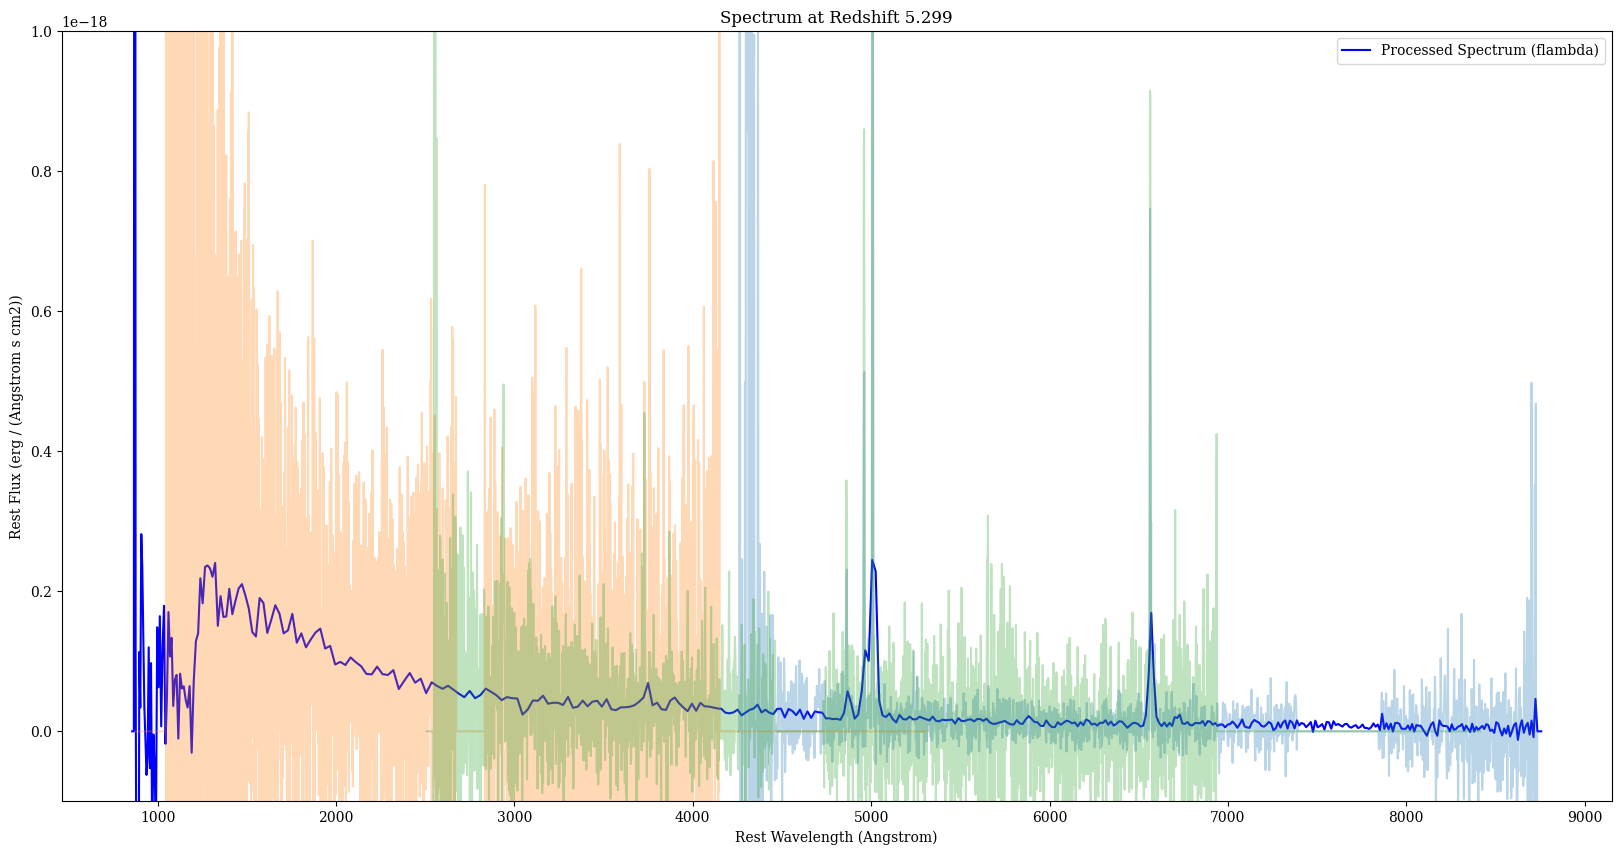

{'prism_filepath': '/home/xingyaocai/DJAv4.2/jades-gdn2-v4/jades-gdn2-v4_prism-clear_1181_721.spec.fits', 'prism_redshift': <Quantity 5.1841>, 'determined_redshift': <Quantity 5.179>, 'grating_filepaths': {'g395m-f290lp': '/home/xingyaocai/DJAv4.2/jades-gdn2-v4/jades-gdn2-v4_g395m-f290lp_1181_721.spec.fits', 'g140m-f070lp': '/home/xingyaocai/DJAv4.2/jades-gdn2-v4/jades-gdn2-v4_g140m-f070lp_1181_721.spec.fits', 'g235m-f170lp': '/home/xingyaocai/DJAv4.2/jades-gdn2-v4/jades-gdn2-v4_g235m-f170lp_1181_721.spec.fits'}, 'grating_redshifts': {'g395m-f290lp': <Quantity 5.1786>, 'g140m-f070lp': <Quantity 5.1831>, 'g235m-f170lp': <Quantity 5.1794>}, 'file_count': 4, 'available_filters': {'g235m-f170lp', 'prism-clear', 'g395m-f290lp', 'g140m-f070lp'}, 'properties': {'redshift_conflict': False}, 'survey_id': 'jades-gdn2-v4', 'sample_flag': True, 'reason_for_exclusion': [], 'grating_slitloss_correction': {'halpha_psf_fraction_f290lp': np.float64(0.825695987905488), 'hbeta_psf_fraction_f290lp': np.fl

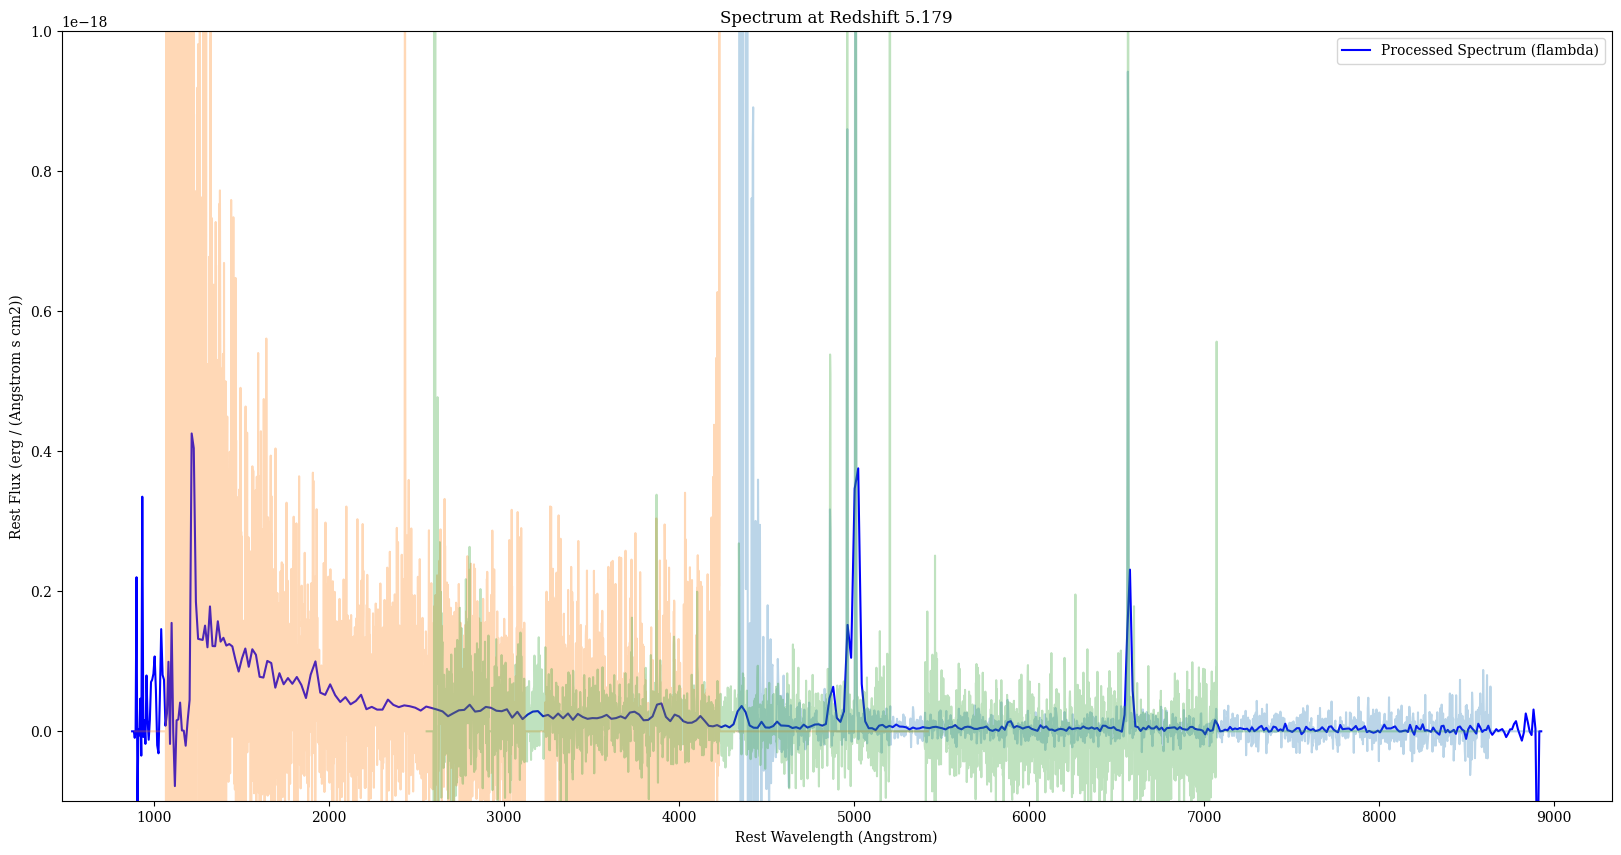

{'prism_filepath': '/home/xingyaocai/DJAv4.2/jades-gdn2-v4/jades-gdn2-v4_prism-clear_1181_1223.spec.fits', 'prism_redshift': <Quantity 6.5967>, 'determined_redshift': <Quantity 6.5924>, 'grating_filepaths': {'g235m-f170lp': '/home/xingyaocai/DJAv4.2/jades-gdn2-v4/jades-gdn2-v4_g235m-f170lp_1181_1223.spec.fits', 'g140m-f070lp': '/home/xingyaocai/DJAv4.2/jades-gdn2-v4/jades-gdn2-v4_g140m-f070lp_1181_1223.spec.fits', 'g395m-f290lp': '/home/xingyaocai/DJAv4.2/jades-gdn2-v4/jades-gdn2-v4_g395m-f290lp_1181_1223.spec.fits'}, 'grating_redshifts': {'g235m-f170lp': <Quantity 6.5924>, 'g140m-f070lp': <Quantity 6.5924>, 'g395m-f290lp': <Quantity 6.5924>}, 'file_count': 4, 'available_filters': {'g235m-f170lp', 'prism-clear', 'g395m-f290lp', 'g140m-f070lp'}, 'properties': {'redshift_conflict': False}, 'survey_id': 'jades-gdn2-v4', 'sample_flag': True, 'reason_for_exclusion': [], 'grating_slitloss_correction': {'halpha_psf_fraction_f170lp': np.float64(0.6214839647022689), 'hbeta_psf_fraction_f170lp':

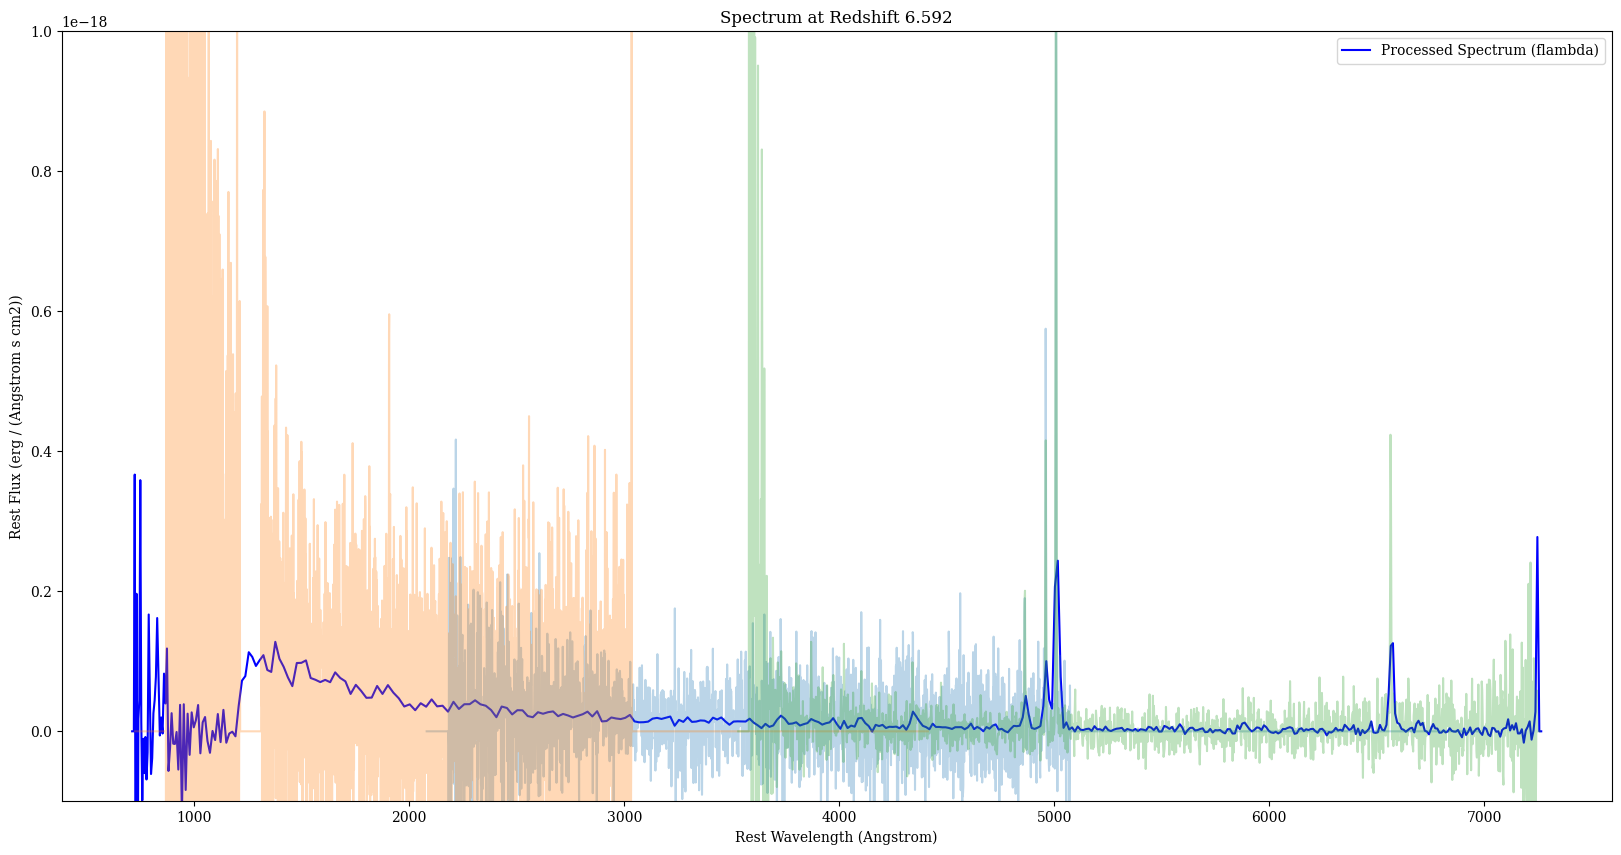

{'prism_filepath': '/home/xingyaocai/DJAv4.2/jades-gdn2-v4/jades-gdn2-v4_prism-clear_1181_2331.spec.fits', 'prism_redshift': <Quantity 3.9703>, 'determined_redshift': <Quantity 3.9664>, 'grating_filepaths': {'g395m-f290lp': '/home/xingyaocai/DJAv4.2/jades-gdn2-v4/jades-gdn2-v4_g395m-f290lp_1181_2331.spec.fits', 'g140m-f070lp': '/home/xingyaocai/DJAv4.2/jades-gdn2-v4/jades-gdn2-v4_g140m-f070lp_1181_2331.spec.fits', 'g235m-f170lp': '/home/xingyaocai/DJAv4.2/jades-gdn2-v4/jades-gdn2-v4_g235m-f170lp_1181_2331.spec.fits'}, 'grating_redshifts': {'g395m-f290lp': <Quantity 3.9664>, 'g140m-f070lp': <Quantity 3.9664>, 'g235m-f170lp': <Quantity 3.9664>}, 'file_count': 4, 'available_filters': {'g235m-f170lp', 'prism-clear', 'g395m-f290lp', 'g140m-f070lp'}, 'properties': {'redshift_conflict': False}, 'survey_id': 'jades-gdn2-v4', 'sample_flag': True, 'reason_for_exclusion': [], 'grating_slitloss_correction': {'halpha_psf_fraction_f070lp': np.float64(0.8747100948223799), 'hbeta_psf_fraction_f070lp':

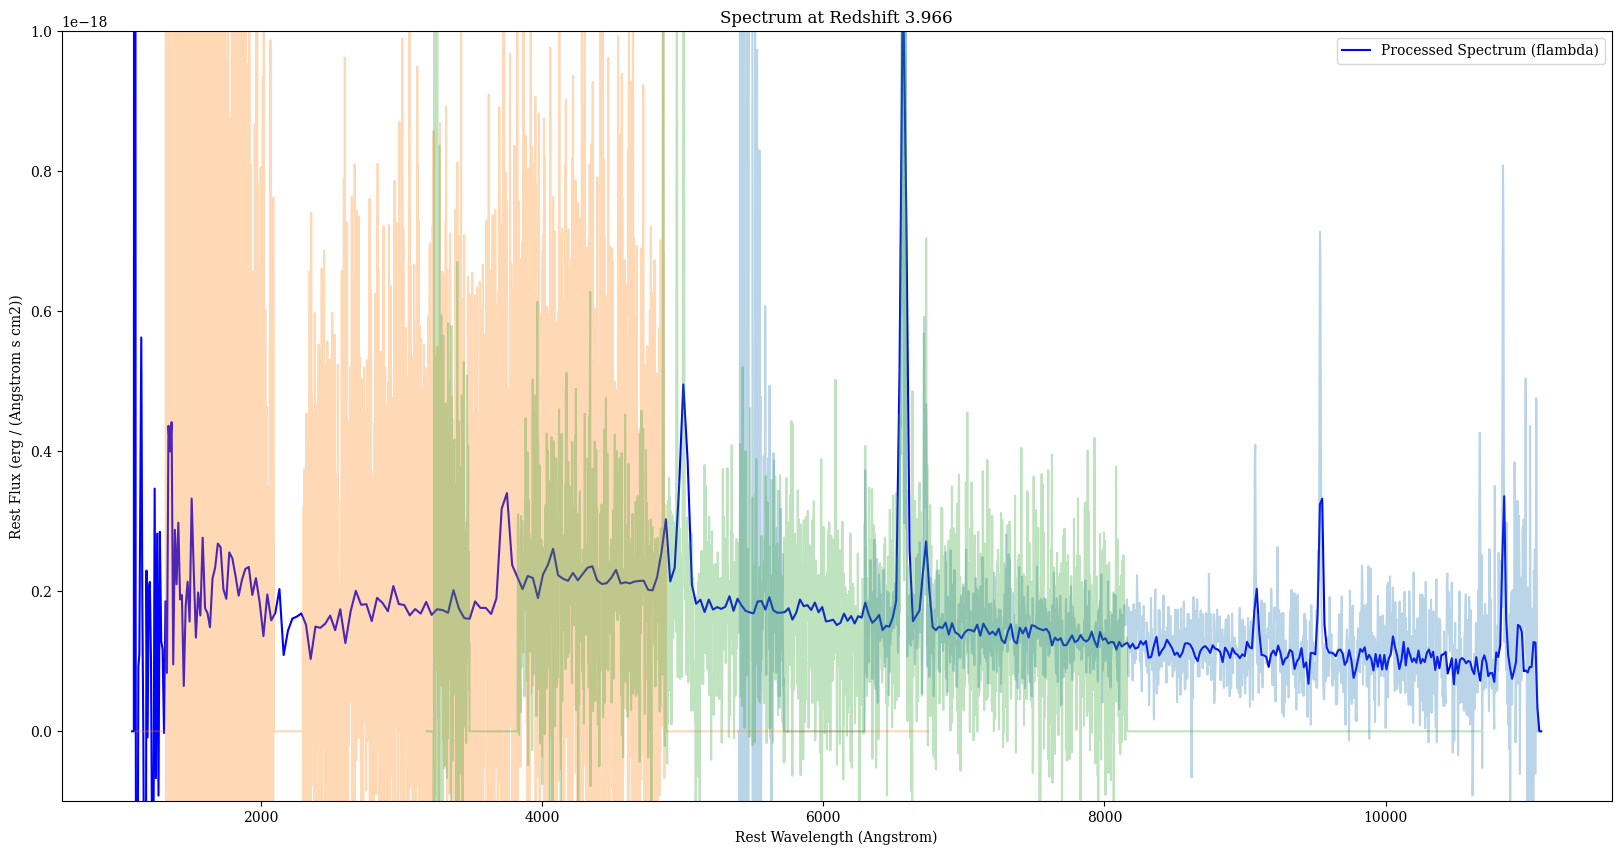

{'prism_filepath': '/home/xingyaocai/DJAv4.2/jades-gdn2-v4/jades-gdn2-v4_prism-clear_1181_1240.spec.fits', 'prism_redshift': <Quantity 3.3353>, 'determined_redshift': <Quantity 3.3347>, 'grating_filepaths': {'g395m-f290lp': '/home/xingyaocai/DJAv4.2/jades-gdn2-v4/jades-gdn2-v4_g395m-f290lp_1181_1240.spec.fits', 'g140m-f070lp': '/home/xingyaocai/DJAv4.2/jades-gdn2-v4/jades-gdn2-v4_g140m-f070lp_1181_1240.spec.fits', 'g235m-f170lp': '/home/xingyaocai/DJAv4.2/jades-gdn2-v4/jades-gdn2-v4_g235m-f170lp_1181_1240.spec.fits'}, 'grating_redshifts': {'g395m-f290lp': <Quantity 3.3342>, 'g140m-f070lp': <Quantity 3.3347>, 'g235m-f170lp': <Quantity 3.3347>}, 'file_count': 4, 'available_filters': {'g235m-f170lp', 'prism-clear', 'g395m-f290lp', 'g140m-f070lp'}, 'properties': {'redshift_conflict': False}, 'survey_id': 'jades-gdn2-v4', 'sample_flag': True, 'reason_for_exclusion': [], 'grating_slitloss_correction': {'halpha_psf_fraction_f070lp': np.float64(0.7847454643711307), 'hbeta_psf_fraction_f070lp':

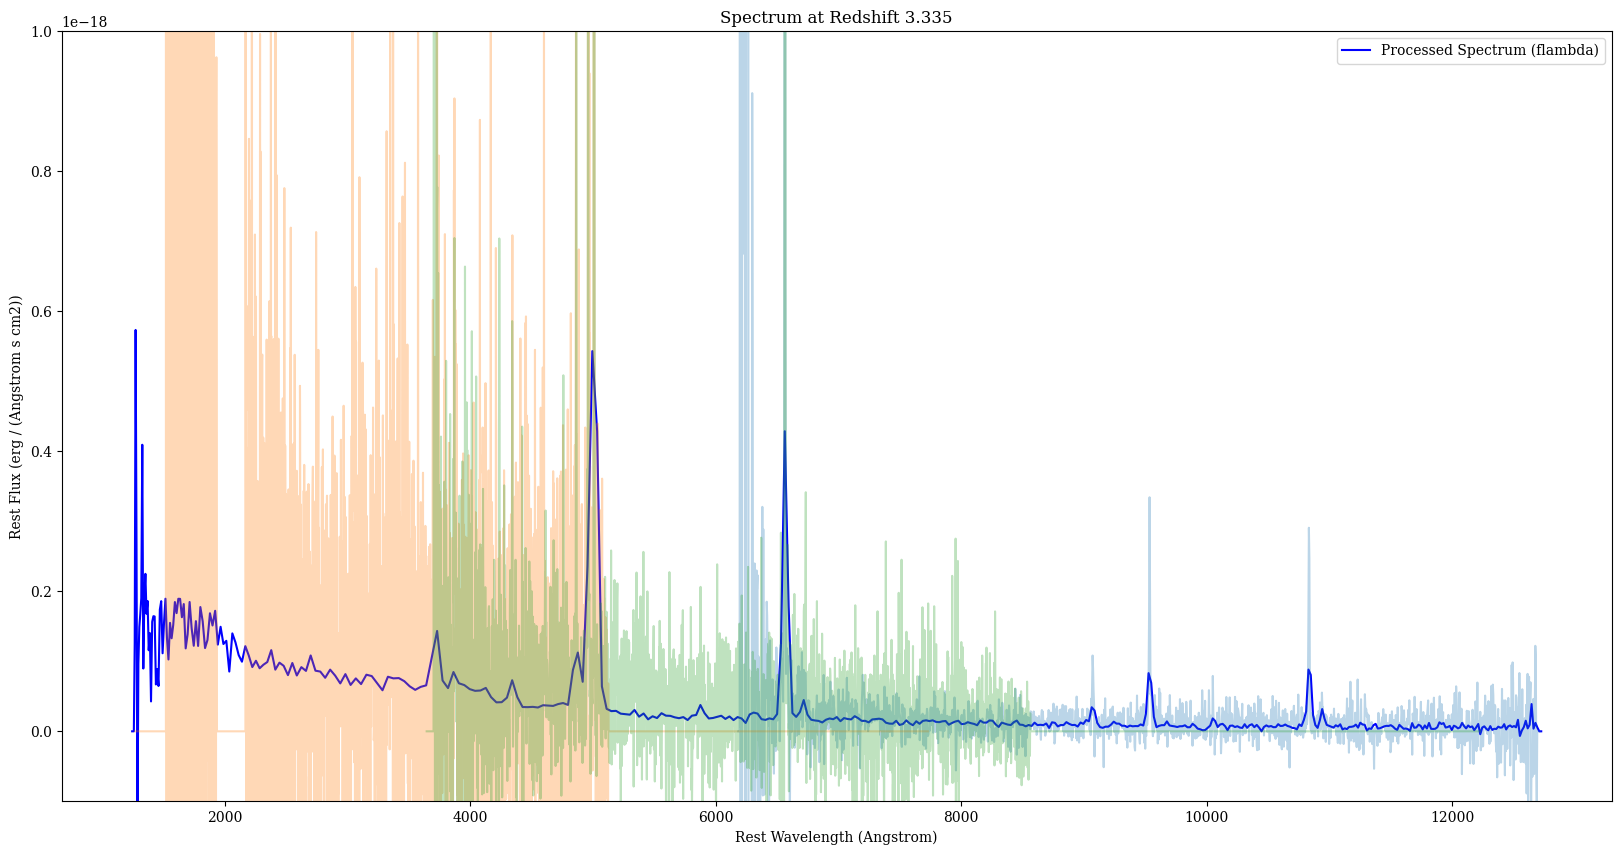

{'prism_filepath': '/home/xingyaocai/DJAv4.2/jades-gdn2-v4/jades-gdn2-v4_prism-clear_1181_31940.spec.fits', 'prism_redshift': <Quantity 3.1308>, 'determined_redshift': <Quantity 3.129>, 'grating_filepaths': {'g235m-f170lp': '/home/xingyaocai/DJAv4.2/jades-gdn2-v4/jades-gdn2-v4_g235m-f170lp_1181_31940.spec.fits', 'g140m-f070lp': '/home/xingyaocai/DJAv4.2/jades-gdn2-v4/jades-gdn2-v4_g140m-f070lp_1181_31940.spec.fits', 'g395m-f290lp': '/home/xingyaocai/DJAv4.2/jades-gdn2-v4/jades-gdn2-v4_g395m-f290lp_1181_31940.spec.fits'}, 'grating_redshifts': {'g235m-f170lp': <Quantity 3.129>, 'g140m-f070lp': <Quantity 3.129>, 'g395m-f290lp': <Quantity 3.129>}, 'file_count': 4, 'available_filters': {'g235m-f170lp', 'prism-clear', 'g395m-f290lp', 'g140m-f070lp'}, 'properties': {'redshift_conflict': False}, 'survey_id': 'jades-gdn2-v4', 'sample_flag': True, 'reason_for_exclusion': [], 'grating_slitloss_correction': {'halpha_psf_fraction_f170lp': np.float64(0.8420591985960603), 'hbeta_psf_fraction_f170lp':

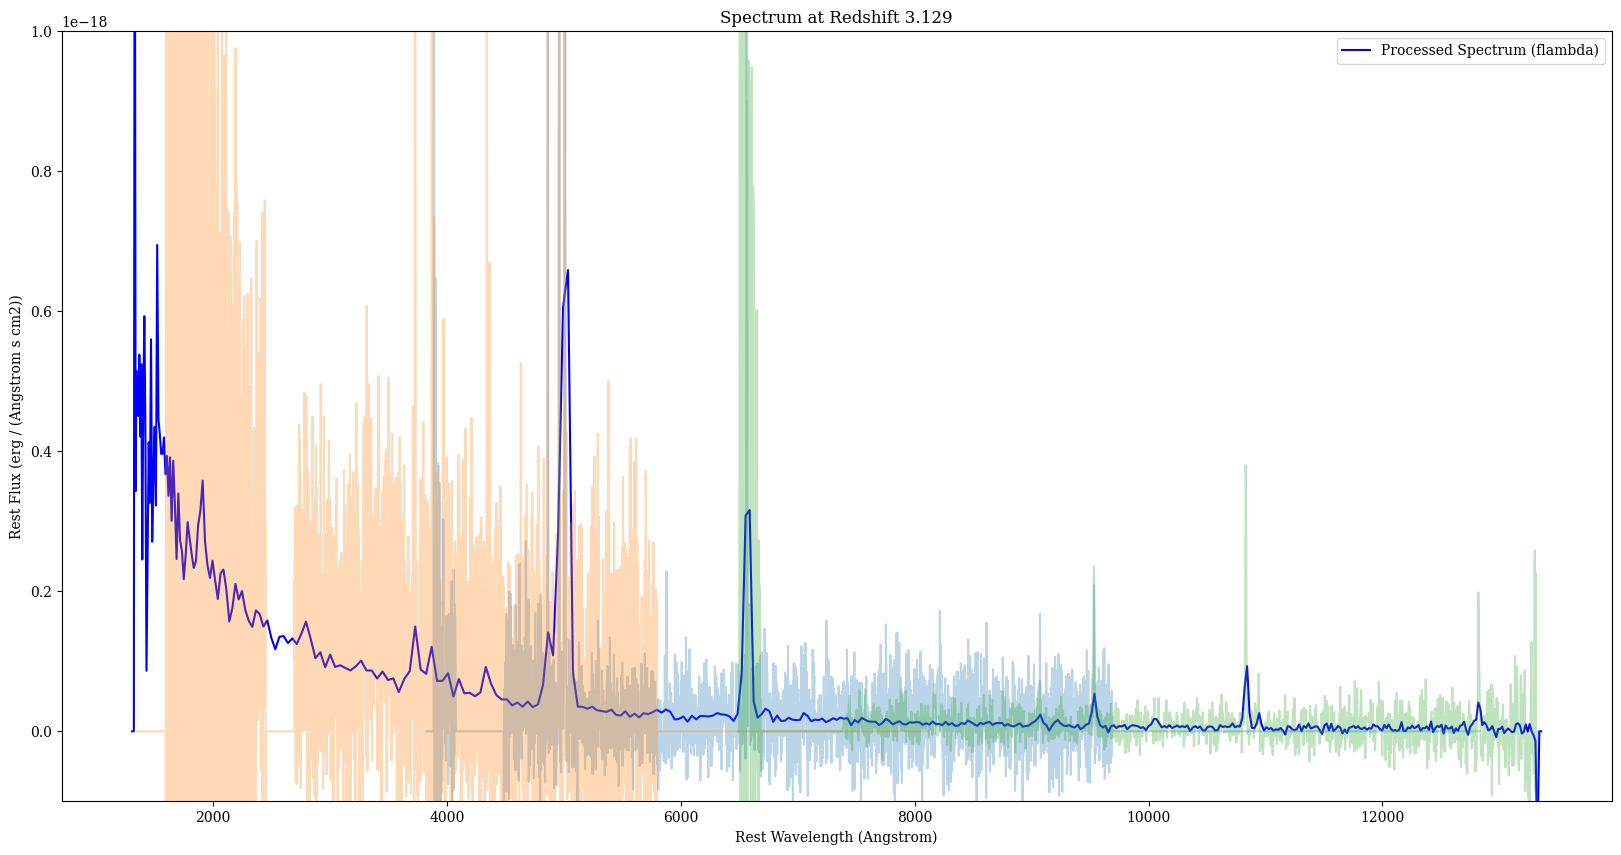

{'prism_filepath': '/home/xingyaocai/DJAv4.2/jades-gdn2-v4/jades-gdn2-v4_prism-clear_1181_804.spec.fits', 'prism_redshift': <Quantity 3.6645>, 'determined_redshift': <Quantity 3.6617>, 'grating_filepaths': {'g140m-f070lp': '/home/xingyaocai/DJAv4.2/jades-gdn2-v4/jades-gdn2-v4_g140m-f070lp_1181_804.spec.fits', 'g235m-f170lp': '/home/xingyaocai/DJAv4.2/jades-gdn2-v4/jades-gdn2-v4_g235m-f170lp_1181_804.spec.fits', 'g395m-f290lp': '/home/xingyaocai/DJAv4.2/jades-gdn2-v4/jades-gdn2-v4_g395m-f290lp_1181_804.spec.fits'}, 'grating_redshifts': {'g140m-f070lp': <Quantity 3.6617>, 'g235m-f170lp': <Quantity 3.6617>, 'g395m-f290lp': <Quantity 3.6617>}, 'file_count': 4, 'available_filters': {'g235m-f170lp', 'prism-clear', 'g395m-f290lp', 'g140m-f070lp'}, 'properties': {'redshift_conflict': False}, 'survey_id': 'jades-gdn2-v4', 'sample_flag': True, 'reason_for_exclusion': [], 'grating_slitloss_correction': {'halpha_psf_fraction_f070lp': np.float64(0.636214088435454), 'hbeta_psf_fraction_f070lp': np.f

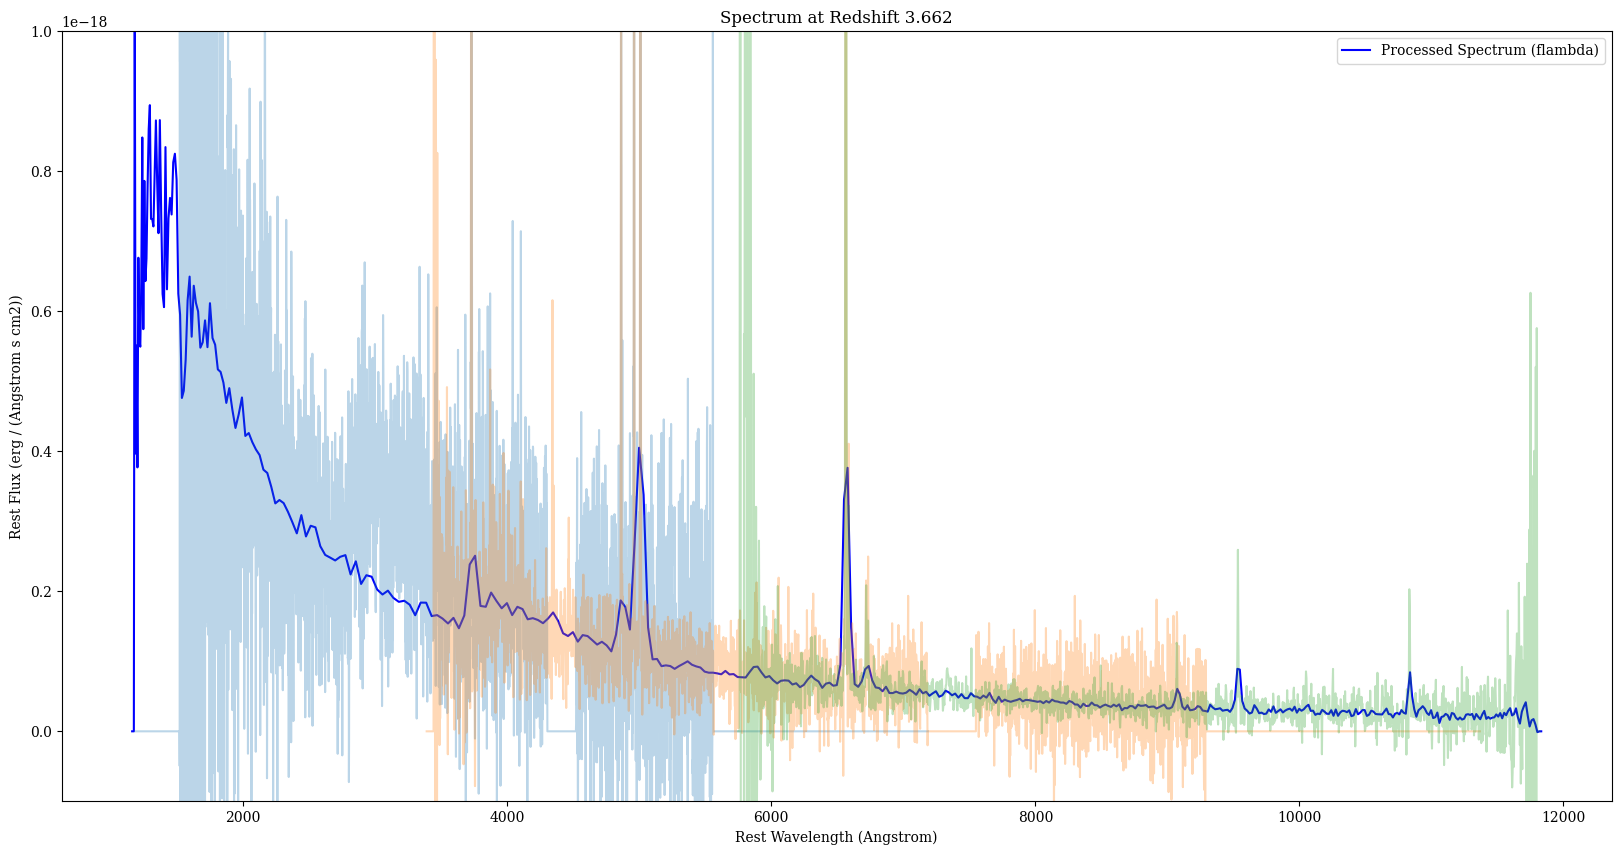

{'prism_filepath': '/home/xingyaocai/DJAv4.2/jades-gdn2-v4/jades-gdn2-v4_prism-clear_1181_1130.spec.fits', 'prism_redshift': <Quantity 3.9729>, 'determined_redshift': <Quantity 3.9692>, 'grating_filepaths': {'g395m-f290lp': '/home/xingyaocai/DJAv4.2/jades-gdn2-v4/jades-gdn2-v4_g395m-f290lp_1181_1130.spec.fits', 'g140m-f070lp': '/home/xingyaocai/DJAv4.2/jades-gdn2-v4/jades-gdn2-v4_g140m-f070lp_1181_1130.spec.fits', 'g235m-f170lp': '/home/xingyaocai/DJAv4.2/jades-gdn2-v4/jades-gdn2-v4_g235m-f170lp_1181_1130.spec.fits'}, 'grating_redshifts': {'g395m-f290lp': <Quantity 3.9685>, 'g140m-f070lp': <Quantity 3.9692>, 'g235m-f170lp': <Quantity 3.9692>}, 'file_count': 4, 'available_filters': {'g235m-f170lp', 'prism-clear', 'g395m-f290lp', 'g140m-f070lp'}, 'properties': {'redshift_conflict': False}, 'survey_id': 'jades-gdn2-v4', 'sample_flag': True, 'reason_for_exclusion': [], 'grating_slitloss_correction': {'halpha_psf_fraction_f070lp': np.float64(0.801711517571935), 'hbeta_psf_fraction_f070lp': 

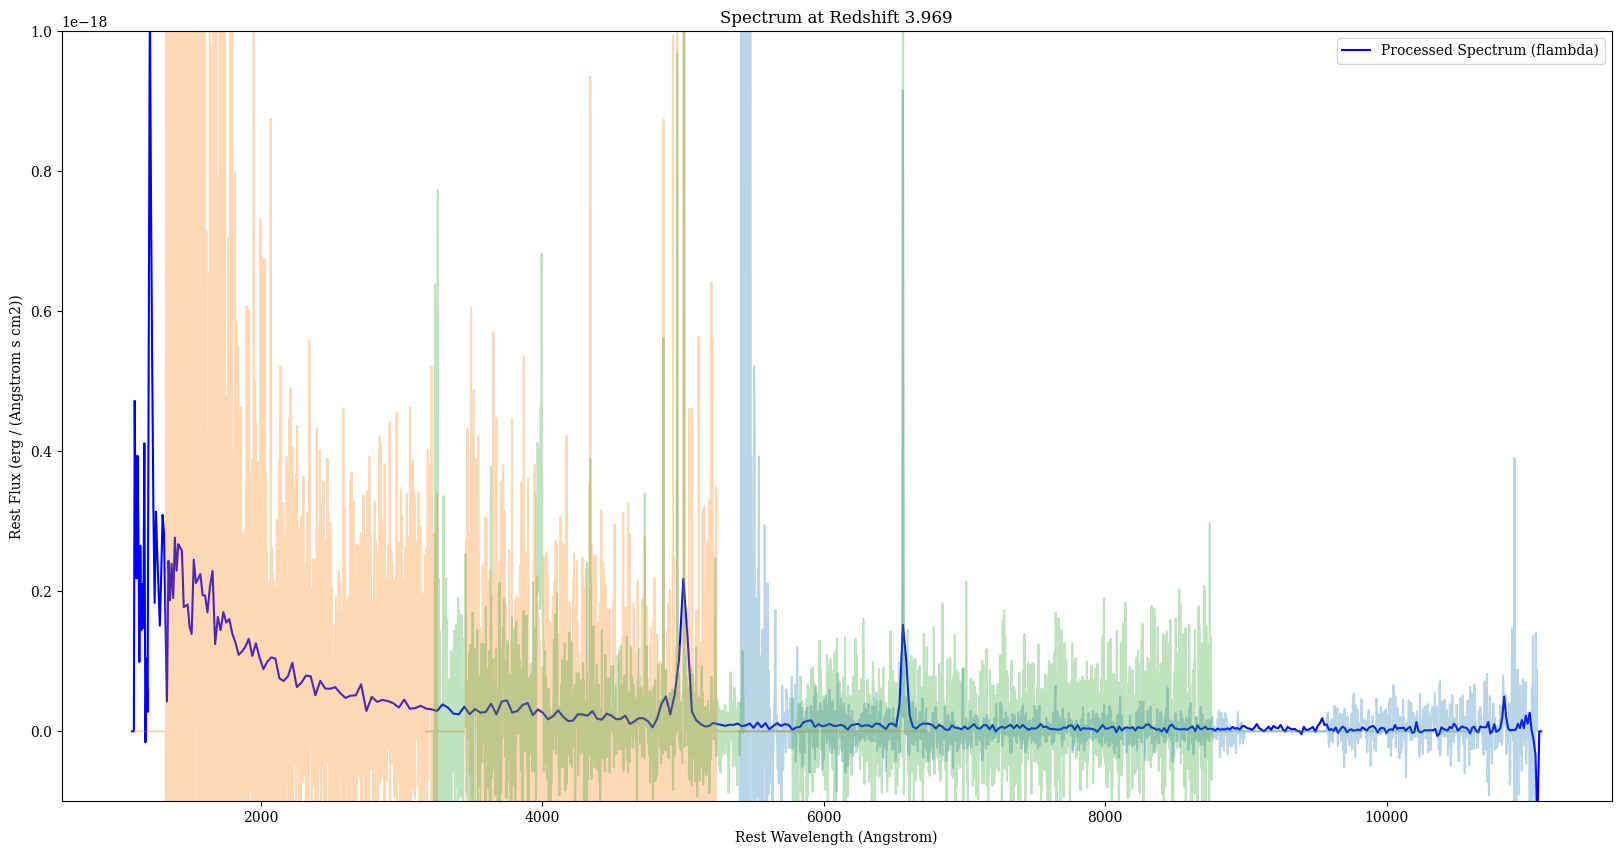

{'prism_filepath': '/home/xingyaocai/DJAv4.2/jades-gdn2-v4/jades-gdn2-v4_prism-clear_1181_604.spec.fits', 'prism_redshift': <Quantity 4.1594>, 'determined_redshift': <Quantity 4.1471>, 'grating_filepaths': {'g235m-f170lp': '/home/xingyaocai/DJAv4.2/jades-gdn2-v4/jades-gdn2-v4_g235m-f170lp_1181_604.spec.fits', 'g140m-f070lp': '/home/xingyaocai/DJAv4.2/jades-gdn2-v4/jades-gdn2-v4_g140m-f070lp_1181_604.spec.fits', 'g395m-f290lp': '/home/xingyaocai/DJAv4.2/jades-gdn2-v4/jades-gdn2-v4_g395m-f290lp_1181_604.spec.fits'}, 'grating_redshifts': {'g235m-f170lp': <Quantity 4.1471>, 'g140m-f070lp': <Quantity 4.1471>, 'g395m-f290lp': <Quantity 4.1477>}, 'file_count': 4, 'available_filters': {'g235m-f170lp', 'prism-clear', 'g395m-f290lp', 'g140m-f070lp'}, 'properties': {'redshift_conflict': False}, 'survey_id': 'jades-gdn2-v4', 'sample_flag': True, 'reason_for_exclusion': [], 'grating_slitloss_correction': {'halpha_psf_fraction_f170lp': np.float64(0.8566439543087613), 'hbeta_psf_fraction_f170lp': np.

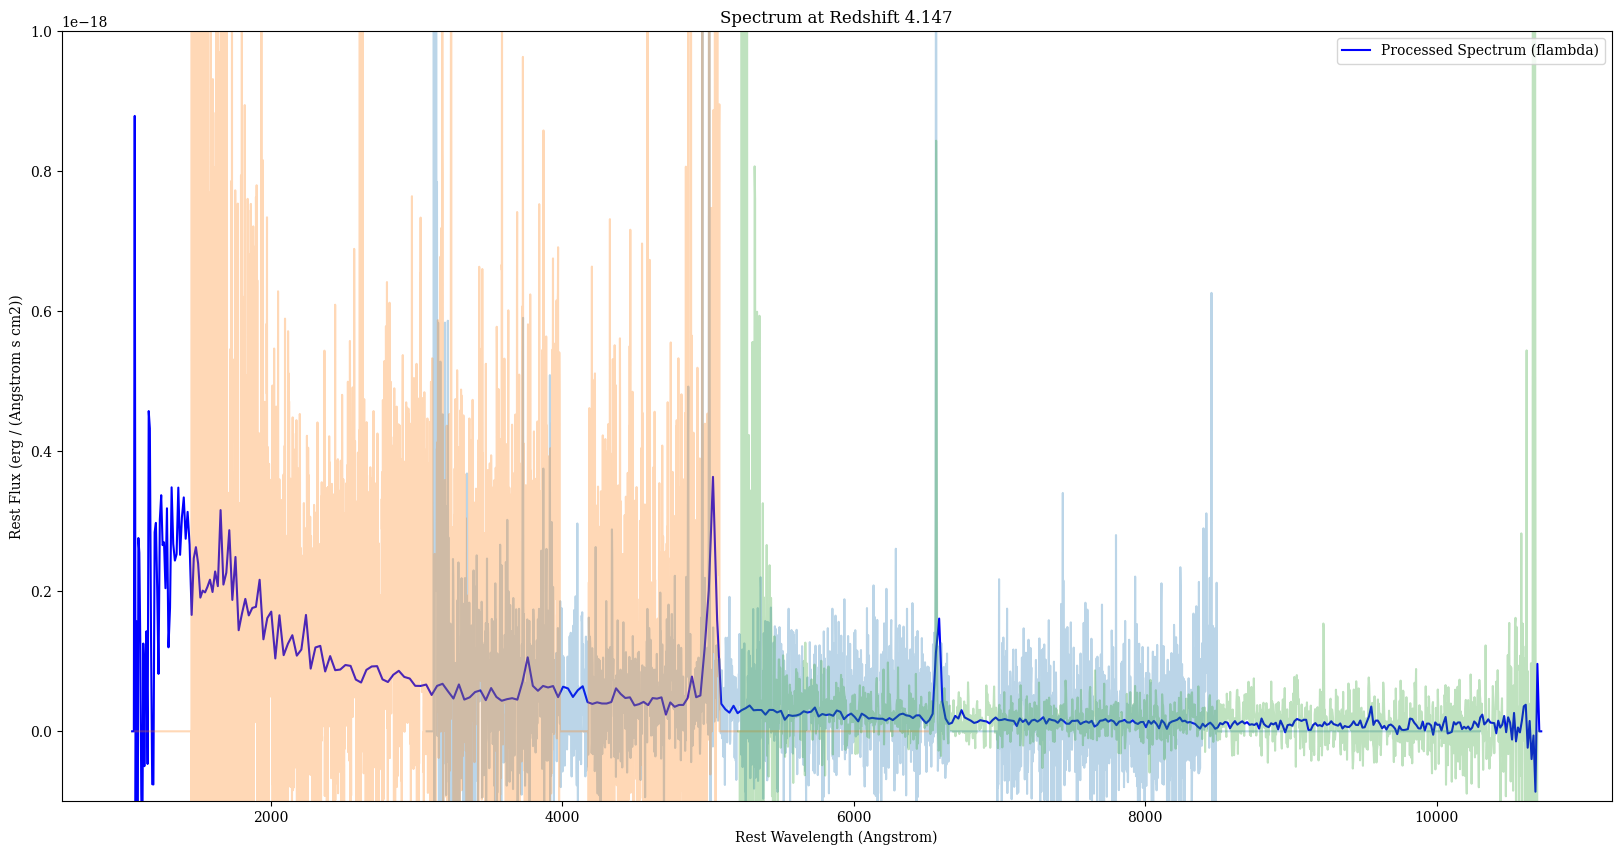

{'prism_filepath': '/home/xingyaocai/DJAv4.2/jades-gdn2-v4/jades-gdn2-v4_prism-clear_1181_1048.spec.fits', 'prism_redshift': <Quantity 3.869>, 'determined_redshift': <Quantity 3.8701>, 'grating_filepaths': {'g235m-f170lp': '/home/xingyaocai/DJAv4.2/jades-gdn2-v4/jades-gdn2-v4_g235m-f170lp_1181_1048.spec.fits', 'g395m-f290lp': '/home/xingyaocai/DJAv4.2/jades-gdn2-v4/jades-gdn2-v4_g395m-f290lp_1181_1048.spec.fits', 'g140m-f070lp': '/home/xingyaocai/DJAv4.2/jades-gdn2-v4/jades-gdn2-v4_g140m-f070lp_1181_1048.spec.fits'}, 'grating_redshifts': {'g235m-f170lp': <Quantity 3.8701>, 'g395m-f290lp': <Quantity 3.8701>, 'g140m-f070lp': <Quantity 3.8708>}, 'file_count': 4, 'available_filters': {'g235m-f170lp', 'prism-clear', 'g395m-f290lp', 'g140m-f070lp'}, 'properties': {'redshift_conflict': False}, 'survey_id': 'jades-gdn2-v4', 'sample_flag': True, 'reason_for_exclusion': [], 'grating_slitloss_correction': {'halpha_psf_fraction_f170lp': np.float64(0.6677503741681715), 'hbeta_psf_fraction_f170lp': 

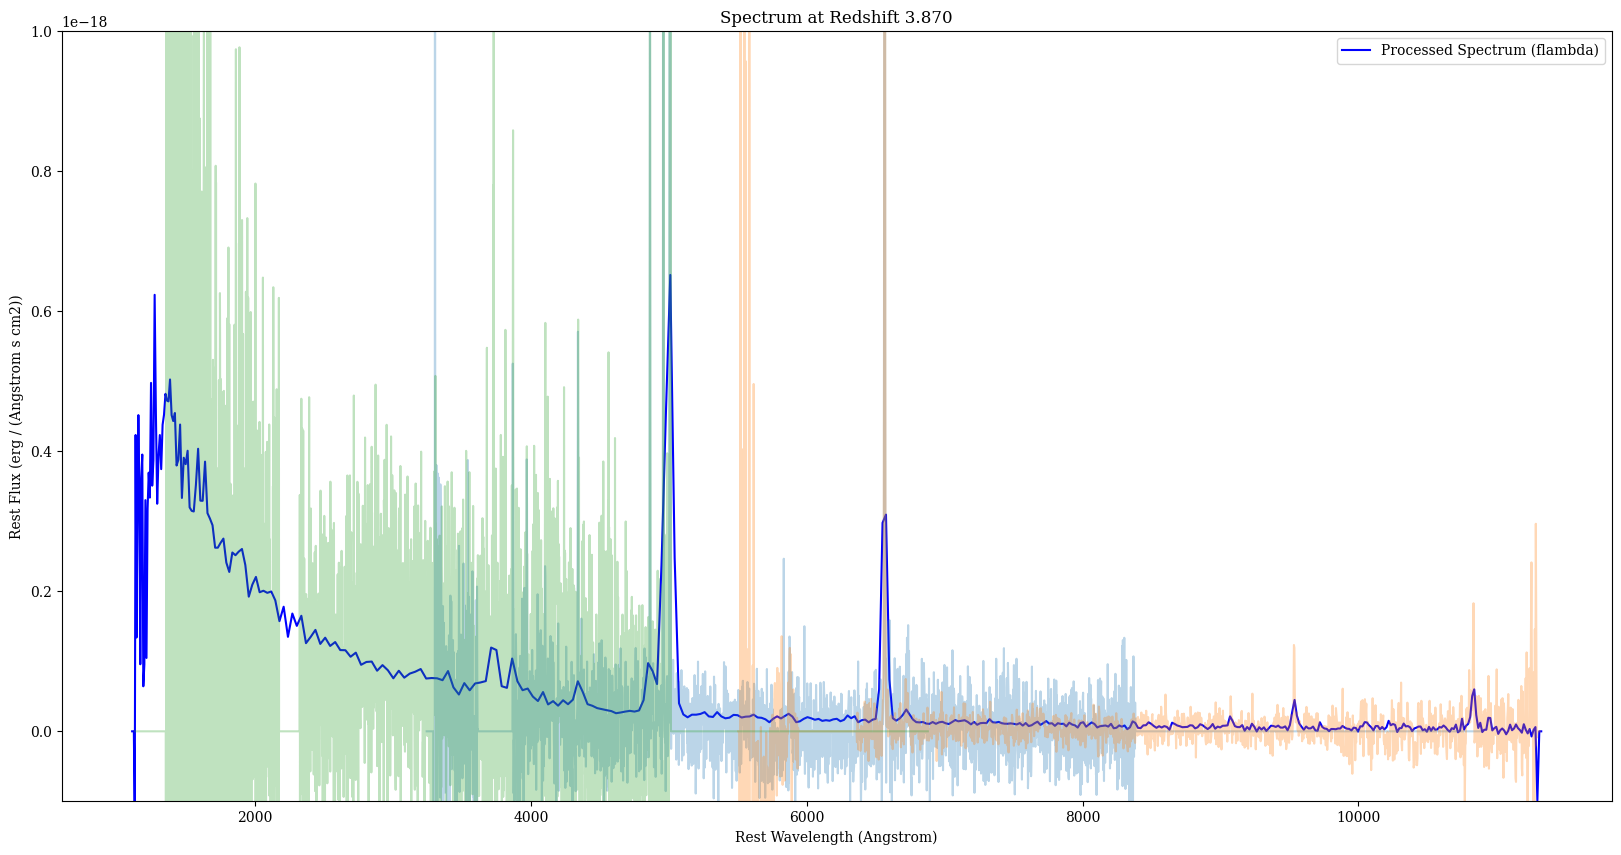

In [ ]:
for surveyid_subid, catalog in DJAv4Catalog.catalog_iterator(1000):
    if not catalog['sample_flag']:
        continue
    print(catalog)
    prism_spex=FL.Load_Spectrum_From_Fits(catalog['prism_filepath'], catalog['determined_redshift'])
    fig, ax=prism_spex.show(if_show=False)
    ax.set_ylim(-1e-19,1e-18)
    # ax.axvline(4850, color='gray', linestyle='--')
    # ax.axvline(5057, color='gray', linestyle='--')

    for filter_name, grating_filepath in catalog['grating_filepaths'].items():
        grating_spex=FL.Load_Spectrum_From_Fits(grating_filepath, catalog['determined_redshift'])
        ax.plot(grating_spex.restframe_wavelengths.convert_unit_to(u.AA), grating_spex.restframe_flux_lambda, label=filter_name,alpha=0.3)


    ax.fill_betweenx([-1e-19,1e-18], 3850, 3950, color='gray', alpha=0.3)

    ax.fill_betweenx([-1e-19,1e-18], 4000, 4100, color='gray', alpha=0.3)





    plt.show()


In [20]:
import ppxf_sew

In [ ]:
高分辨率的对continuum不是很敏感
